<div align="center">

#####

#Teoría de Circuitos 2

##Trabajo Práctico N°6

**Estudiante: Nahir Lewartowski**

</div>

---

##**Red T**

###**Matriz MAI**



$$MAI = \begin{bmatrix} Y_L & 0 & 0 & -Y_L \\ 0 & Y_L & 0 & -Y_L \\ 0 & 0 & Y_C & -Y_C \\ -Y_L & -Y_L & -Y_C & 2Y_L + Y_C \end{bmatrix}$$


$$MAI = \frac{1}{\frac{2}{sL} + sC} \begin{bmatrix} \frac{1}{s^2L^2} + \frac{C}{L} & -\frac{1}{s^2L^2} & -\frac{C}{L} \\ -\frac{1}{s^2L^2} & \frac{1}{s^2L^2} + \frac{C}{L} & -\frac{C}{L} \\ -\frac{C}{L} & -\frac{C}{L} & \frac{2C}{L} \end{bmatrix}$$

###**Cofactores**

$$\frac{V_{23}}{V_{13}} = \frac{\Delta_{13}^{23}}{\Delta_{13}^{13}} = \frac{-Y_{21}}{Y_{22}} = \frac{-(-Y_L^2)}{Y_L^2 + Y_L Y_C} = \frac{1}{1 + s^2 LC}$$

$$\frac{V_{21}}{V_{31}} = \frac{\Delta_{31}^{21}}{\Delta_{31}^{31}} = \frac{-Y_{23}}{Y_{22}} = \frac{-(-Y_L Y_C)}{Y_L^2 + Y_L Y_C} = \frac{s^2 LC}{1 + s^2 LC}$$

$$\frac{V_{12}}{V_{32}} = \frac{\Delta_{32}^{12}}{\Delta_{32}^{32}} = \frac{-Y_{13}}{Y_{11}} = \frac{-(-Y_L Y_C)}{Y_L^2 + Y_L Y_C} = \frac{s^2 LC}{1 + s^2 LC}$$

###**Respuesta módulo y fase**

**Transferencia $T_a$**:

$T_a(j\omega) = \frac{1}{1-\omega^2LC}$

Módulo: Arranca en 0 dB en bajas frecuencias. A medida que se acerca a $\omega_0$, sube abruptamente hacia el infinito. Pasando $\omega_0$, empieza a caer con una pendiente de -40 dB/década.

Fase: Arranca en $0^\circ$, en $\omega_0$ pasa abruptamente a $-180^\circ$ y se mantiene para las frecuencias altas.

**Transferencia $T_b$**:

$T_b(j\omega) = \frac{-\omega^2LC}{1-\omega^2LC}$

Módulo: Para bajas frecuencias tiene una pendiente de +40 dB/década, con su pico infinito en $\omega_0$, y para las frecuencias altas se aplana en 0 dB.

Fase: Arranca en $+180^\circ$, en $\omega_0$ baja a $0^\circ$ y se mantiene así para frecuencias mayores.

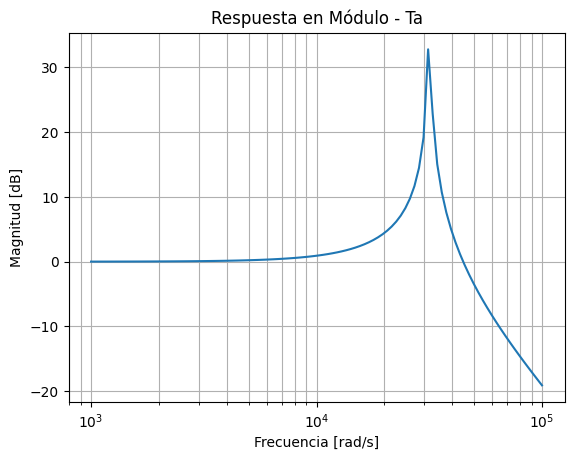

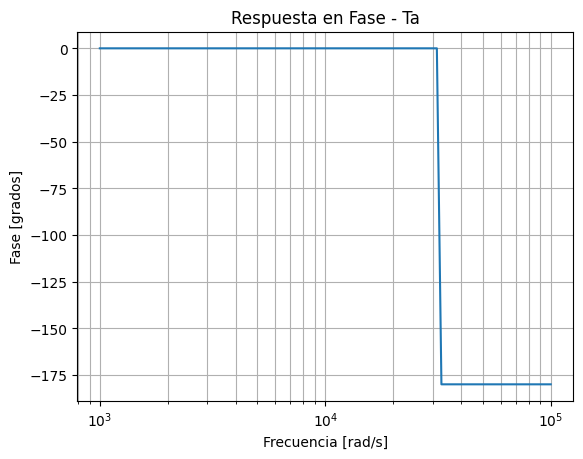

In [5]:
import scipy.signal as sig
import matplotlib.pyplot as plt

L = 1e-3
C = 1e-6

num = [1]
den = [L*C, 0, 1]

sistema = sig.TransferFunction(num, den)

w, mag, phase = sig.bode(sistema)

plt.figure()
plt.semilogx(w, mag)
plt.title('Respuesta en Módulo - Ta')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which="both", ls="-")
plt.show()

plt.figure()
plt.semilogx(w, phase)
plt.title('Respuesta en Fase - Ta')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Fase [grados]')
plt.grid(True, which="both", ls="-")
plt.show()

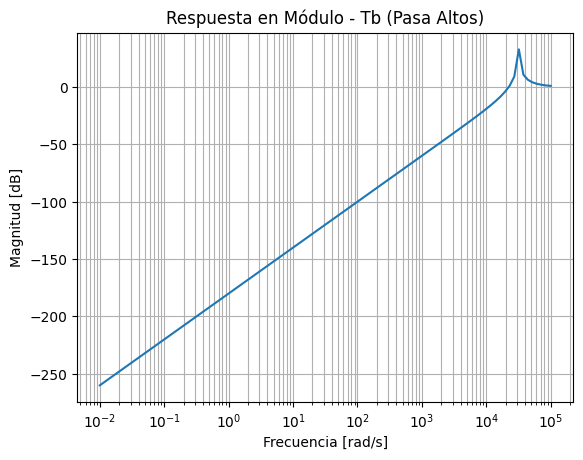

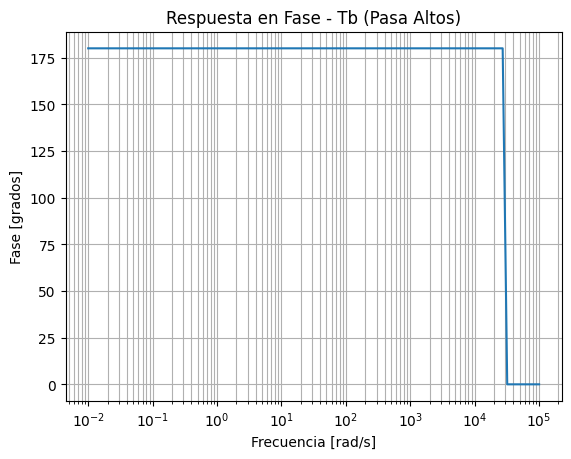

In [6]:
import scipy.signal as sig
import matplotlib.pyplot as plt

L = 1e-3
C = 1e-6

num = [L*C, 0, 0]
den = [L*C, 0, 1]

sistema = sig.TransferFunction(num, den)

w, mag, phase = sig.bode(sistema)

plt.figure()
plt.semilogx(w, mag)
plt.title('Respuesta en Módulo - Tb (Pasa Altos)')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which="both", ls="-")
plt.show()

plt.figure()
plt.semilogx(w, phase)
plt.title('Respuesta en Fase - Tb (Pasa Altos)')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Fase [grados]')
plt.grid(True, which="both", ls="-")
plt.show()

###**Complementarias en módulo**

$$\vert{}T_a + T_b\vert{} = \left\vert{} \frac{1}{1 + s^2 LC} + \frac{s^2 LC}{1 + s^2 LC} \right\vert{} = \left\vert{} \frac{1 + s^2 LC}{1 + s^2 LC} \right\vert{} = \vert{}1\vert{} = 1$$

##**MOS**

###**Matriz MAI**

$$MAI = \begin{bmatrix} sC_{iss} & -sC_{rss} & -s(C_{iss}-C_{rss}) \\ g_m - sC_{rss} & sC_{oss} & -g_m - s(C_{oss}-C_{rss}) \\ -g_m - s(C_{iss}-C_{rss}) & -s(C_{oss}-C_{rss}) & g_m + s(C_{iss} + C_{oss} - 2C_{rss}) \end{bmatrix}$$

###**Matriz Y para Source y Drain común**

$$Y_{Source} = \begin{bmatrix} sC_{iss} & -sC_{rss} \\ g_m - sC_{rss} & sC_{oss} \end{bmatrix}$$

$$Y_{Drain} = \begin{bmatrix} sC_{iss} & -s(C_{iss}-C_{rss}) \\ -g_m - s(C_{iss}-C_{rss}) & g_m + s(C_{iss} + C_{oss} - 2C_{rss}) \end{bmatrix}$$

###**Matriz T Source común**

$$\Delta Y_{CS} = Y_{11}Y_{22} - Y_{12}Y_{21} = (sC_{iss})(sC_{oss}) - (-sC_{rss})(g_m - sC_{rss}$$

$$\Delta Y_{CS} = s^2(C_{iss}C_{oss} - C_{rss}^2) + s g_m C_{rss}$$

$$\begin{bmatrix} A & B \\ C & D \end{bmatrix} = \begin{bmatrix} \frac{-Y_{22}}{Y_{21}} & \frac{-1}{Y_{21}} \\ \frac{-\Delta Y_{CS}}{Y_{21}} & \frac{-Y_{11}}{Y_{21}} \end{bmatrix}$$

$$T_{Source} = \frac{1}{g_m - sC_{rss}} \begin{bmatrix} -sC_{oss} & -1 \\ -[s^2(C_{iss}C_{oss} - C_{rss}^2) + s g_m C_{rss}] & -sC_{iss} \end{bmatrix}$$

##**Bonus**

In [7]:
import sympy as sp
from IPython.display import display, Math

s, L, C = sp.symbols('s L C', complex=True)

YL = 1 / (s * L)
YC = s * C

MAI_4x4 = sp.Matrix([
    [ YL,   0,   0, -YL],
    [  0,  YL,   0, -YL],
    [  0,   0,  YC, -YC],
    [-YL, -YL, -YC, 2*YL + YC]
])

print("MAI 4x4 original:")
display(Math(r'MAI_{4x4} = ' + sp.latex(MAI_4x4)))

Y_ee = MAI_4x4[:3, :3]
Y_ei = MAI_4x4[:3, 3:]
Y_ie = MAI_4x4[3:, :3]
Y_ii = MAI_4x4[3:, 3:]

MAI_3x3 = sp.simplify(Y_ee - Y_ei * Y_ii.inv() * Y_ie)

print("\nMAI 3x3 reducida:")
display(Math(r'MAI_{3x3} = ' + sp.latex(MAI_3x3)))

T_23_13 = sp.simplify(-MAI_3x3[1, 0] / MAI_3x3[1, 1])
print("\nTransferencia V23 / V13:")
display(Math(r'\frac{V_{23}}{V_{13}} = ' + sp.latex(T_23_13)))

T_21_31 = sp.simplify(-MAI_3x3[1, 2] / MAI_3x3[1, 1])
print("\nTransferencia V21 / V31:")
display(Math(r'\frac{V_{21}}{V_{31}} = ' + sp.latex(T_21_31)))

T_12_32 = sp.simplify(-MAI_3x3[0, 2] / MAI_3x3[0, 0])
print("\nTransferencia V12 / V32:")
display(Math(r'\frac{V_{12}}{V_{32}} = ' + sp.latex(T_12_32)))

MAI 4x4 original:


<IPython.core.display.Math object>


MAI 3x3 reducida:


<IPython.core.display.Math object>


Transferencia V23 / V13:


<IPython.core.display.Math object>


Transferencia V21 / V31:


<IPython.core.display.Math object>


Transferencia V12 / V32:


<IPython.core.display.Math object>